<a href="https://colab.research.google.com/github/kfartem434-png/MN_Kapusta/blob/main/%D0%9B%D0%912_2_%D0%9A%D0%B0%D0%BF%D1%83%D1%81%D1%82%D0%B0_3_12_%D0%A2%D0%B8%D1%82%D0%B0%D0%BD%D1%96%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install pandas --upgrade

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os

In [8]:
print(np.__version__)
print(pd.__version__)

2.1.3
2.2.3


In [9]:
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")
df = pd.read_csv(os.path.join(path,"titanic.csv"))
print(len(df))
print(df.shape)
print(df.columns.values)
df.head(10)

100%|██████████| 22.0k/22.0k [00:00<00:00, 20.7MB/s]

Extracting files...
891
(891, 12)
['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Датафрейм має розмірність 891 рядків та 12 стовпців.

Стовпці зберігають такі дані:

**PassengerId**: ідентифікатор пасажира;

**Survived**: булеве значення індикуюче чи вижив пасажир;

**Pclass**: клас пасажира, 3 -- найнижчий, 1 --найвищий;

**Name**: ім'я пасажира;

**Sex**: стать пасажира;

**Age**: вік пасажира;

**SibSp**: кількість братів/сестер яких має пасажир;

**Parch**: кількість батьків/дітей яких має пасажир;

**Ticket**: номер квитка;

**Fare**: вартість квитка;

**Cabin**: номер кабіни;

**Embarked**: звідки відправився пасажир.

Серед даних стовпців, номер кабіни та відправлення пасажиру не були задокументовані в описі датасету.

In [10]:
print("Дуплікати: \n\n",df.loc[df.duplicated()],end="\n\n")
print("Кількість NA: \n\n",df.isna().sum(),end="\n\n")

Дуплікати: 

 Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []

Кількість NA: 

 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64



Датасет не має дуплікатів, але має пропуски в стопцях віку, номерів кабін та місця відправлення.

In [11]:
df["Age"].fillna(df["Age"].median(skipna=True))

df.drop("Cabin",axis=1,inplace=True)
df.drop("Embarked",axis=1,inplace=True)

In [17]:
df["Sex"] = df["Sex"].map({"male": 0,"female": 1})

In [18]:
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


В описі числових даних датафрейму можна побачити, що серед задокументованих пасажирів вижило приблизно 38,4%.

**Середьностатистичний клас пасажира**: 2,3, що співпадає з описом стовпчика про те, що 3 -- найнижчий клас.

**Відсоток жінок на кораблі**: 35%;

**Відсоток чоловіків**: 65%;

**Середній вік пасажирів**: 30 років;

**Cередня кількість братів/сестер**: 0,5; Середня кількість батьків/дітей пасажира: 0,4.

In [13]:
print("Кількість пасажирів з безкоштовним квитком: \n\n",(df["Fare"].loc[df["Fare"] == 0] + 1).sum(),end="\n\n")

Кількість пасажирів з безкоштовним квитком: 

 15.0



Як було видно з числового опису -- на борту Титаніка були пасажири які не платили за перевезення. Кількість таких пасажирів приблизно збігається з інформацією про людей що отримали безкоштовні квитки.

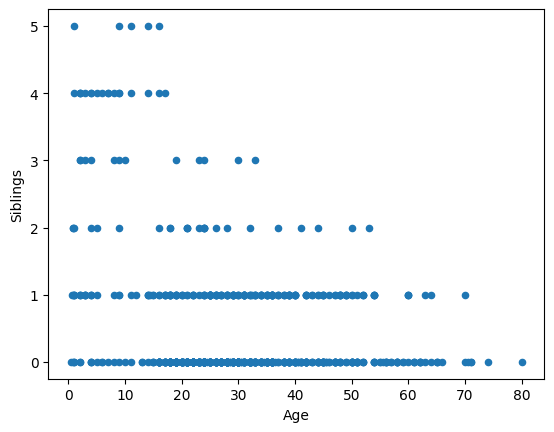

In [15]:
df.plot(kind="scatter",x="Age",y="SibSp")
plt.title("")
plt.ylabel("Siblings")
plt.show()

З графіку видно, що велика кількість людей на титаніку не мали братів чи систер, при цьому, для тих хто мали, кількість братів/сестер корелює з меньшим віком.

In [16]:
print("Кореляція між віком та кількістю братів/сестер: \n\n",df["Age"].corr(df["SibSp"].loc[df["SibSp"] != 0]),end="\n\n")

Кореляція між віком та кількістю братів/сестер: 

 -0.45700223759174163



Обчислення коефіцієнта кореляції Пірсона показав, що вище зазначений висновок є коректним: існує середня негативна кореляція між віком та кількістю братів/сестер, тобто збільшення віку призводить до зменшення кількості братів/сестер.

In [19]:
survived_by_age = df[["PassengerId","Age","Survived"]].groupby("Age").agg(
  Total_passengers=("PassengerId","nunique"),
  Survived_total=("Survived","sum")
)
survived_by_age["Survival_rate"] = survived_by_age["Survived_total"]/survived_by_age["Total_passengers"]
print(survived_by_age.tail(20))

      Total_passengers  Survived_total  Survival_rate
Age                                                  
53.0                 1               1          1.000
54.0                 8               3          0.375
55.0                 2               1          0.500
55.5                 1               0          0.000
56.0                 4               2          0.500
57.0                 2               0          0.000
58.0                 5               3          0.600
59.0                 2               0          0.000
60.0                 4               2          0.500
61.0                 3               0          0.000
62.0                 4               2          0.500
63.0                 2               2          1.000
64.0                 2               0          0.000
65.0                 3               0          0.000
66.0                 1               0          0.000
70.0                 2               0          0.000
70.5                 1      

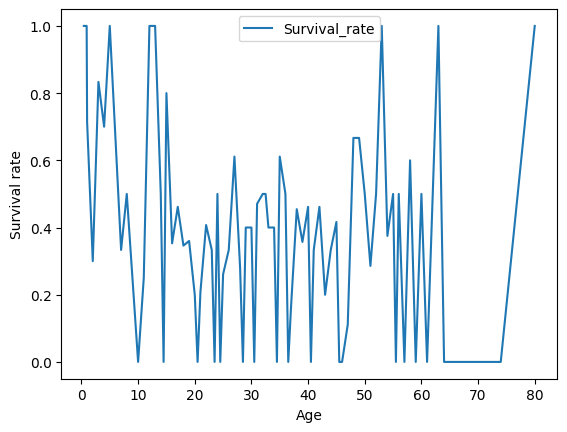

Коефіцієнт кореляції: 

 -0.28611331475672575



In [20]:
survived_by_age.plot(kind="line",y="Survival_rate")
plt.ylabel("Survival rate")
plt.show()
print("Коефіцієнт кореляції: \n\n",pd.Series(survived_by_age.index).corr(survived_by_age["Survival_rate"]),end="\n\n")

З графіку та значення кореляції можна визначити, що існує низька негативна кореляція між віком та шансом вижити. Можна також помітити плато нулів між віком 64 та 74 роки. Це можна пояснити як помилку при збирані даних для датасета, де вік виживших було взято після катастрофи (Про це можна прочитати в статті ["Did a male octogenarian really survive the sinking of the RMS Titanic?"](https://mjboothaus.wordpress.com/2017/07/11/did-a-male-octogenarian-really-survive-the-sinking-of-the-rms-titanic-2/) на платформі wordpress). Якщо відкинути дані віком від 64 до 80 років, то графік має форму літери U -- люди молодші та старші за віком від 32 років мають вищий шанс вижити.

In [21]:
survival_by_class = df[["PassengerId","Pclass","Survived"]].groupby("Pclass").agg(
  Total_passengers=("PassengerId","nunique"),
  Survived_total=("Survived","sum")
)
survival_by_class["Survival_rate"] = survival_by_class["Survived_total"]/survival_by_class["Total_passengers"]
print(survival_by_class.head(10))

        Total_passengers  Survived_total  Survival_rate
Pclass                                                 
1                    216             136       0.629630
2                    184              87       0.472826
3                    491             119       0.242363


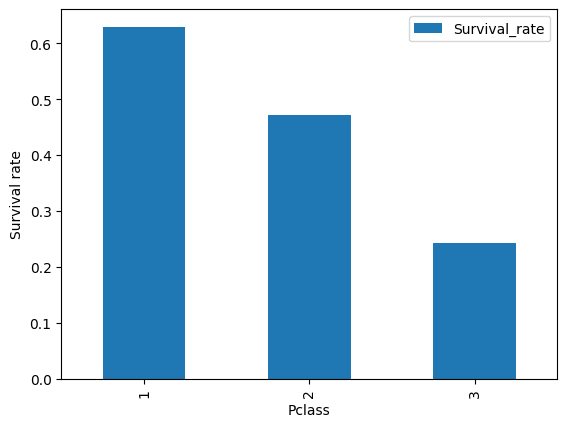

Коефіцієнт кореляції: 

 -0.9999999999999999



In [22]:
survival_by_class.plot(kind="bar",y="Survival_rate")
plt.ylabel("Survival rate")
plt.show()
print("Коефіцієнт кореляції: \n\n",pd.Series(survival_by_class.index).corr(survival_by_class["Survival_rate"]),end="\n\n")

З графіку та значення кореляції можна побачити, що існує майже ідеальна кореляція між класом пасажира та його шансом виживання. Відповідно, найвищий шанс виживання мають пасажири першого класу.

In [75]:
survival_by_sex = df[["PassengerId","Sex","Survived"]].groupby("Sex").agg(
  Total_passengers=("PassengerId","nunique"),
  Survived_total=("Survived","sum")
)
survival_by_sex["Survival_rate"] = survival_by_sex["Survived_total"]/survival_by_sex["Total_passengers"]
survival_by_sex

,Total_passengers,Survived_total,Survival_rate
Sex,,,
0,577,109,0.188908
1,314,233,0.742038


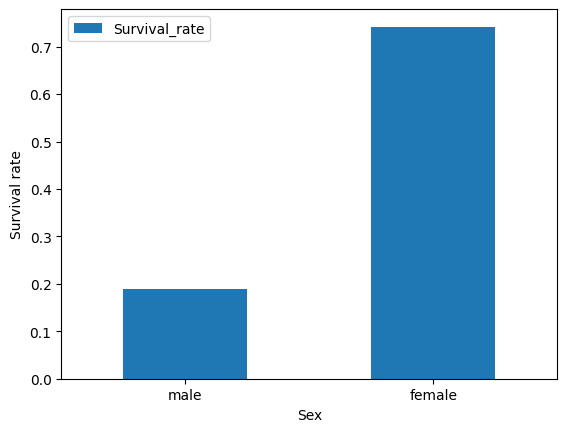

Коефіцієнт кореляції: 

 1.0



In [76]:
survival_by_sex.plot(kind="bar",y="Survival_rate")
locs, labels = plt.xticks()
plt.xticks(locs,("male","female"))
plt.tick_params(axis="x",rotation=0)
plt.ylabel("Survival rate")
plt.show()
print("Коефіцієнт кореляції: \n\n",pd.Series(survival_by_sex.index).corr(survival_by_sex["Survival_rate"]),end="\n\n")

З графіку легко побачити, що жінки мали набагато вищий шанс вижити під час катастрофи ніж чоловіки.

In [59]:
fare_quantiles = pd.qcut(df["Fare"],10)
survival_by_fare_quantiles = pd.DataFrame(
  data={"PassengerId": df["PassengerId"],"Fare": fare_quantiles,"Survived": df["Survived"]}
).groupby("Fare").agg(Total_passengers=("PassengerId","nunique"),Survived_total=("Survived","sum"))
survival_by_fare_quantiles["Survival_rate"] = (
  survival_by_fare_quantiles["Survived_total"]
  / survival_by_fare_quantiles["Total_passengers"]
)
survival_by_fare_quantiles.head(10)

/tmp/ipykernel_580/164196708.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby("Fare").agg(Total_passengers=("PassengerId","nunique"),Survived_total=("Survived","sum"))


,Total_passengers,Survived_total,Survival_rate
Fare,,,
"(-0.001, 7.55]",92,13,0.141304
"(7.55, 7.854]",87,26,0.298851
"(7.854, 8.05]",106,19,0.179245
"(8.05, 10.5]",78,18,0.230769
"(10.5, 14.454]",84,36,0.428571
"(14.454, 21.679]",88,37,0.420455
"(21.679, 27.0]",89,46,0.516854
"(27.0, 39.688]",91,34,0.373626
"(39.688, 77.958]",89,47,0.528090


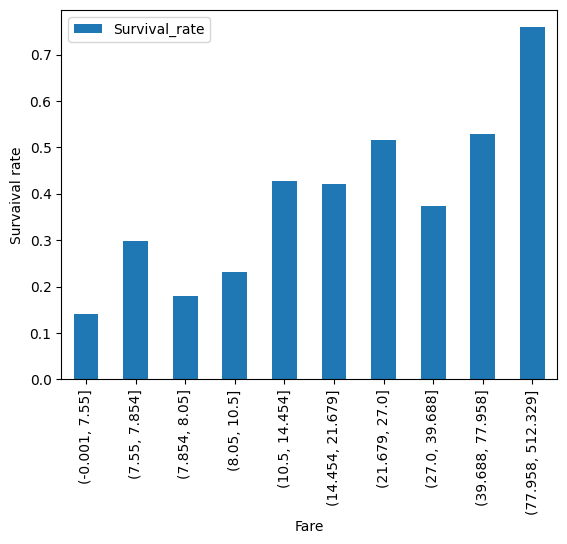

Коефіцієнт кореляції: 

 0.9620177060547281



In [73]:
survival_by_fare_quantiles.plot(kind="bar",y="Survival_rate")
plt.ylabel("Survaival rate")
plt.show()
survival_rate = survival_by_fare_quantiles["Survival_rate"]
print(
  "Коефіцієнт кореляції: \n\n",
  pd.Series(survival_by_fare_quantiles.index).map(lambda x: (x.left + x.right)/2)
    .corr(pd.Series(survival_rate,index=np.arange(len(survival_rate)))),
  end="\n\n"
)

Як видно з графіку, існує позитивна кореляція між вартістю квитка та шансом виживання. Коефіцієнт кореляції Пірсона є близьким до одиниці, що підтверджує візуальний аналіз графіка.